In [28]:
# 📘 UTS Data Mining : Analisis Imbalanced Data
# Anggota Kelompok : - Muhammad Zahran Albara (122140240)
#                    - Casey Z.D Manurung (122140054)
#                    - Royfran Roger Valentino (122140239)
# Prodi: Teknik Informatika

# Tujuan:
# Menunjukkan proses lengkap analisis imbalanced data mulai dari eksplorasi, preprocessing, modeling, hingga penyeimbangan menggunakan SMOTE.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import entropy

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

In [30]:

# 1️⃣ Baca seluruh file dan buang tanda kutip & baris kosong
with open("Dataset_UTS - Pembelian.csv", encoding="utf-8") as f:
    lines = [line.strip().replace('"', '') for line in f if line.strip()]

data = []
current_kode = None
current_produk = None
current_unit = None

# 2️⃣ Loop semua baris
for line in lines:
    # Lewati header
    if line.startswith("KODE") or line.startswith("TANGGAL"):
        continue

    # Deteksi baris kode produk (misal: A000001 ANATON TAB STRIP)
    match_kode = re.match(r'^(A\d+)\s+(.+?)\s+([A-Z]+)$', line)
    if match_kode:
        current_kode = match_kode.group(1)
        current_produk = match_kode.group(2).strip()
        current_unit = match_kode.group(3).strip()
        continue

    # Deteksi baris transaksi (misal: 06-07-21  1.13-210706.0908-003  10,00  2.520,00)
    match_trans = re.match(r'^\s*(\d{2}-\d{2}-\d{2})\s+([\w\.\-]+)\s+([\d,]+)\s+([\d\.,]+)', line)
    if match_trans and current_kode:
        tanggal = match_trans.group(1)
        no_trans = match_trans.group(2)
        qty = match_trans.group(3).replace(",", ".")
        nilai = match_trans.group(4).replace(".", "").replace(",", ".")
        data.append({
            "KODE": current_kode,
            "NAMA PRODUK": current_produk,
            "UNIT": current_unit,
            "TANGGAL": tanggal,
            "NO.TRANSAKSI": no_trans,
            "QTY.MSK": float(qty),
            "NILAI.MSK": float(nilai)
        })

# 3️⃣ Ubah ke DataFrame
df_pembelian = pd.DataFrame(data)

# 4️⃣ Simpan hasil bersih
df_pembelian.to_csv("Dataset_Pembelian_clean.csv", index=False)
print(f"✅ Parsing selesai! {len(df_pembelian)} baris transaksi berhasil dibersihkan.")
df_pembelian.head(10)

✅ Parsing selesai! 138346 baris transaksi berhasil dibersihkan.


,KODE,NAMA PRODUK,UNIT,TANGGAL,NO.TRANSAKSI,QTY.MSK,NILAI.MSK
0,A000001,ANATON TAB,STRIP,06-07-21,1.13-210706.0908-003,10.0,2520.0
1,A000001,ANATON TAB,STRIP,12-07-21,2.6-210712.1519-097,1.0,3000.0
2,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1633-013,1.0,3000.0
3,A000001,ANATON TAB,STRIP,12-07-21,2.13-210712.1807-013,1.0,3000.0
4,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1855-018,1.0,3000.0
5,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1925-027,1.0,3000.0
6,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1957-035,1.0,3000.0
7,A000001,ANATON TAB,STRIP,12-07-21,2.6-210712.0907-023,2.0,3000.0
8,A000001,ANATON TAB,STRIP,13-07-21,2.11-210713.1102-011,1.0,3000.0
9,A000001,ANATON TAB,STRIP,13-07-21,2.6-210713.1701-006,1.0,4000.0


In [31]:

src = "Dataset UTS - Stok.csv"
out = "Dataset_Stok_clean.csv"

with open(src, "r", encoding="utf-8") as f:
    raw_lines = [ln.strip().replace('"', '') for ln in f.readlines()]

# Hapus baris kosong dan garis pemisah
lines = [ln for ln in raw_lines if ln and set(ln.strip()) != {'-'}]

# Temukan header (perluas pencarian header agar lebih fleksibel)
header_idx = None
for i, ln in enumerate(lines):
    if re.search(r'KODE', ln, re.IGNORECASE) and re.search(r'QTY', ln, re.IGNORECASE):
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Header STOK tidak ditemukan.")

stok_lines = lines[header_idx + 1:]

unit_candidates = set(["STRIP","BTL","BOTOL","BOX","PCS","SACHET","KAPSUL","TABLET","TAB","AMP","ML","MG","POT","PSG"])
lokasi_pattern = re.compile(r'^(ETL|RAK|GDG|GUDANG|LEMARI)', re.IGNORECASE)

records = []

for ln in stok_lines:
    ln = ln.strip()
    if not ln:
        continue

    # Perluas regex qty: cari angka di akhir atau di tengah, dengan lebih toleran terhadap format
    qty_match = re.search(r'(\d+(?:[\.,]\d{1,3})?)(?:\s*(\w+))?\s*$', ln)
    if not qty_match:
        # Jika tidak ada qty di akhir, coba cari di mana saja di baris
        qty_match = re.search(r'(\d+(?:[\.,]\d{1,3})?)', ln)
        if not qty_match:
            continue
        qty_raw = qty_match.group(1)
        qty_num = float(qty_raw.replace('.', '').replace(',', '.'))
        after_qty = ""  # Tidak ada token setelah qty
        cut_pos = ln.find(qty_raw) + len(qty_raw)
        left = ln[:cut_pos].strip()
    else:
        qty_raw = qty_match.group(1)
        qty_num = float(qty_raw.replace('.', '').replace(',', '.'))
        after_qty = qty_match.group(2) or ""
        cut_pos = ln.rfind(qty_raw)
        left = ln[:cut_pos].strip()

    # Perluas regex kode: dari A\d+ menjadi alfanumerik lebih umum (misal A123, B456, atau kode lain)
    code_match = re.match(r'^([A-Z0-9]+)\s+(.*)$', left)
    if not code_match:
        # Jika tidak match, coba pola lebih luas: ambil token pertama sebagai kode
        tokens = left.split()
        if tokens:
            kode = tokens[0]
            rest = " ".join(tokens[1:])
        else:
            continue
    else:
        kode = code_match.group(1)
        rest = code_match.group(2).strip()

    # Pisah token
    tokens = rest.split()
    lokasi = ""
    nama_tokens = []

    # Cari lokasi dari token yang mirip ETL / RAK / GUDANG / dsb (tetap sama, tapi bisa perluas jika perlu)
    for i, tok in enumerate(tokens):
        if lokasi_pattern.match(tok):
            lokasi = tok
            nama_tokens = tokens[:i]
            break
    else:
        lokasi = ""
        nama_tokens = tokens

    nama_produk = " ".join(nama_tokens)
    unit = ""

    # Jika after_qty adalah unit valid, pakai itu
    if after_qty.upper() in unit_candidates:
        unit = after_qty.upper()
    else:
        # fallback: coba cari unit dari dalam nama (tetap sama)
        for u in unit_candidates:
            if re.search(rf'\b{u}\b', nama_produk, re.IGNORECASE):
                unit = u
                break

    records.append({
        "KODE": kode,
        "NAMA PRODUK": nama_produk.strip(),
        "LOKASI": lokasi.strip(),
        "QTY.STOK": qty_num,
        "UNIT": unit.strip()
    })

# Buat dataframe
df_stok = pd.DataFrame(records, columns=["KODE","NAMA PRODUK","LOKASI","QTY.STOK","UNIT"])
df_stok["NAMA PRODUK"] = df_stok["NAMA PRODUK"].str.replace(r'\s+', ' ', regex=True).str.strip()
df_stok.dropna(subset=["KODE","NAMA PRODUK","QTY.STOK"], inplace=True)
df_stok.reset_index(drop=True, inplace=True)

df_stok.to_csv(out, index=False)
print(f"✅ Selesai - {len(df_stok)} baris stok berhasil dibersihkan dan disimpan ke `{out}`")
display(df_stok.head(15))

✅ Selesai - 1518 baris stok berhasil dibersihkan dan disimpan ke `Dataset_Stok_clean.csv`


,KODE,NAMA PRODUK,LOKASI,QTY.STOK,UNIT
0,A000001,ANATON TAB,ETL1,12.0,STRIP
1,A00001,ACTIVED HIJAU,ETL3A,2.0,BTL
2,A000012,APIALYS SYR 100 ML,ETL3A,2.0,BTL
3,A000014,ALKOHOL 1000 ML,ETL3B,7.0,BTL
4,A000016,ALLOPURINOL 300,RAK2,40.0,STRIP
5,A000018,ATORVASTATIN 10MG,RAK2,6.0,STRIP
6,A00004,ACYCLOVIR 200MG,RAK2,13.0,STRIP
7,A000040,MEFIX 500MG,RAK1,9.0,STRIP
8,A00005,ACYCLOVIR 400MG,RAK2,21.0,STRIP
9,A000066,ANDALAN KB FE,RAK4,35.0,STRIP


In [32]:
# Gabungkan kedua dataframe berdasarkan kolom "KODE"
df_merged = pd.merge(
    df_pembelian,
    df_stok[["KODE", "LOKASI", "QTY.STOK"]],
    on="KODE",
    how="left"
)

print(f"Jumlah baris sebelum gabung: {len(df_pembelian)}")
print(f"Jumlah baris sesudah gabung: {len(df_merged)}")

# Cek hasil awal
display(df_merged.head(5))


Jumlah baris sebelum gabung: 138346
Jumlah baris sesudah gabung: 138346


,KODE,NAMA PRODUK,UNIT,TANGGAL,NO.TRANSAKSI,QTY.MSK,NILAI.MSK,LOKASI,QTY.STOK
0,A000001,ANATON TAB,STRIP,06-07-21,1.13-210706.0908-003,10.0,2520.0,ETL1,12.0
1,A000001,ANATON TAB,STRIP,12-07-21,2.6-210712.1519-097,1.0,3000.0,ETL1,12.0
2,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1633-013,1.0,3000.0,ETL1,12.0
3,A000001,ANATON TAB,STRIP,12-07-21,2.13-210712.1807-013,1.0,3000.0,ETL1,12.0
4,A000001,ANATON TAB,STRIP,12-07-21,2.11-210712.1855-018,1.0,3000.0,ETL1,12.0


Distribusi kategori setelah simulasi:
kategori
Obat Bebas           95.11876
Obat Resep Dokter     4.88124
Name: proportion, dtype: float64


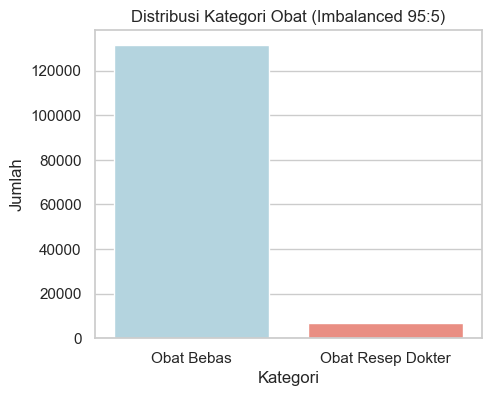

In [46]:

# simulasi imbalanced data
np.random.seed(42)
df_merged["kategori"] = np.random.choice(
    ["Obat Bebas", "Obat Resep Dokter"],
    size=len(df_merged),
    p=[0.95, 0.05]
)

print("Distribusi kategori setelah simulasi:")
print(df_merged["kategori"].value_counts(normalize=True) * 100)

# Visualisasi distribusi kategori
plt.figure(figsize=(5,4))
sns.countplot(x=df_merged["kategori"], hue=df_merged["kategori"], palette=["lightblue", "salmon"], legend=False)
plt.title("Distribusi Kategori Obat (Imbalanced 95:5)")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.show()

In [34]:
# ==============================================================
# 🧹 4️⃣ PERSIAPAN DATA UNTUK MODELING
# ==============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Fitur dan target
X = df_merged.drop(columns=["kategori"])
y = df_merged["kategori"]

# Label encoding untuk kolom kategorikal
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Split data (stratify menjaga rasio kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# ==============================================================
# 🧼 Tangani Missing Value Setelah Penggabungan 
# ==============================================================

print("Jumlah missing sebelum imputasi:")
print(df_merged.isna().sum())

# Imputasi aman tanpa inplace=True
df_merged["QTY.STOK"] = df_merged["QTY.STOK"].fillna(df_merged["QTY.STOK"].median())
df_merged["LOKASI"] = df_merged["LOKASI"].fillna("Tidak Diketahui")

print("\nSetelah imputasi:")
print(df_merged.isna().sum())


Jumlah missing sebelum imputasi:
KODE                 0
NAMA PRODUK          0
UNIT                 0
TANGGAL              0
NO.TRANSAKSI         0
QTY.MSK              0
NILAI.MSK            0
LOKASI          126317
QTY.STOK        126317
kategori             0
dtype: int64

Setelah imputasi:
KODE            0
NAMA PRODUK     0
UNIT            0
TANGGAL         0
NO.TRANSAKSI    0
QTY.MSK         0
NILAI.MSK       0
LOKASI          0
QTY.STOK        0
kategori        0
dtype: int64


In [ ]:
# ==============================================================
# 🔧Tangani NaN Langsung di X_train dan X_test
# ==============================================================

from sklearn.impute import SimpleImputer

# Buat imputer untuk semua kolom numerik
imputer = SimpleImputer(strategy="median")

# Pastikan semuanya dalam bentuk DataFrame (bukan numpy)
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Verifikasi
print("Sisa missing value di X_train:", X_train.isna().sum().sum())
print("Sisa missing value di X_test:", X_test.isna().sum().sum())


Sisa missing value di X_train: 0
Sisa missing value di X_test: 0


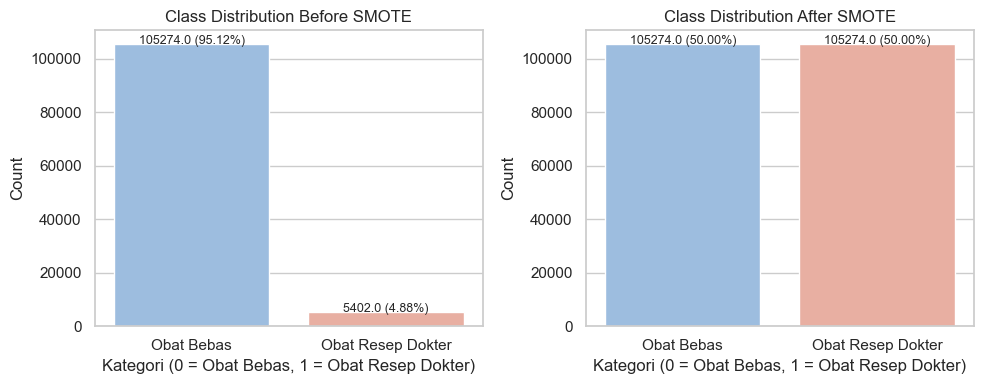

=== Distribusi Sebelum SMOTE ===
kategori
Obat Bebas           95.12
Obat Resep Dokter     4.88
Name: proportion, dtype: float64

=== Distribusi Sesudah SMOTE ===
kategori
Obat Bebas           50.0
Obat Resep Dokter    50.0
Name: proportion, dtype: float64


In [44]:
# ==============================================================
# ⚖️ RESAMPLING DATA MENGGUNAKAN SMOTE + VISUALISASI
# ==============================================================

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1️⃣ Pisahkan fitur dan target
X = df_merged.drop(columns=["kategori"])
y = df_merged["kategori"]

# 2️⃣ Label encoding untuk kolom kategorikal (agar bisa diproses oleh SMOTE)
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 3️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4️⃣ SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# ==============================================================
# 📊 Visualisasi Distribusi Kelas Sebelum & Sesudah SMOTE
# ==============================================================

plt.figure(figsize=(10, 4))

# Sebelum SMOTE
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x=y_train, hue=y_train, palette=["#92BCEA", "#F4A896"], legend=False)
total1 = len(y_train)
for p in ax1.patches:
    height = p.get_height()
    percentage = 100 * height / total1
    ax1.text(p.get_x() + p.get_width()/2., height + 5,
             f'{height} ({percentage:.2f}%)',
             ha="center", fontsize=9)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Kategori (0 = Obat Bebas, 1 = Obat Resep Dokter)")
plt.ylabel("Count")

# Sesudah SMOTE
plt.subplot(1, 2, 2)
ax2 = sns.countplot(x=y_res, hue=y_res, palette=["#92BCEA", "#F4A896"], legend=False)
total2 = len(y_res)
for p in ax2.patches:
    height = p.get_height()
    percentage = 100 * height / total2
    ax2.text(p.get_x() + p.get_width()/2., height + 5,
             f'{height} ({percentage:.2f}%)',
             ha="center", fontsize=9)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Kategori (0 = Obat Bebas, 1 = Obat Resep Dokter)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# ==============================================================
# 🧾 Statistik Ringkas
# ==============================================================

before_stats = y_train.value_counts(normalize=True) * 100
after_stats = y_res.value_counts(normalize=True) * 100

print("=== Distribusi Sebelum SMOTE ===")
print(before_stats.round(2))
print("\n=== Distribusi Sesudah SMOTE ===")
print(after_stats.round(2))


In [47]:
# ==============================================================
# 🧾 Contoh Perbandingan Data Sebelum dan Sesudah SMOTE
# ==============================================================

# Gabungkan fitur dan label agar mudah dibandingkan
df_before = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
df_after = pd.concat([X_res, y_res], axis=1)

print("=== Sebelum SMOTE (10 contoh acak) ===")
display(df_before.sample(10, random_state=42))

print("\n=== Sesudah SMOTE (10 contoh acak) ===")
display(df_after.sample(10, random_state=42))


=== Sebelum SMOTE (10 contoh acak) ===


,KODE,NAMA PRODUK,UNIT,TANGGAL,NO.TRANSAKSI,QTY.MSK,NILAI.MSK,LOKASI,QTY.STOK,kategori
44609,126,70,2,94,1173,2.0,35394.13,12,37.0,Obat Bebas
50207,126,70,2,88,2998,1.0,6000.00,12,37.0,Obat Bebas
274,45,84,10,163,32834,12.0,2791.67,7,74.0,Obat Bebas
15321,126,70,2,228,11171,10.0,1550.00,12,37.0,Obat Bebas
105516,126,70,2,212,52616,1.0,1500.00,12,37.0,Obat Bebas
19209,126,70,2,275,8736,3.0,3500.00,12,37.0,Obat Bebas
51729,126,70,2,92,35928,1.0,45000.00,12,37.0,Obat Bebas
23418,126,70,2,75,15497,1.0,8500.00,12,37.0,Obat Bebas
24672,126,70,2,280,26072,1.0,2500.00,12,37.0,Obat Bebas
20512,126,70,2,73,53721,1.0,10000.00,12,37.0,Obat Bebas



=== Sesudah SMOTE (10 contoh acak) ===


,KODE,NAMA PRODUK,UNIT,TANGGAL,NO.TRANSAKSI,QTY.MSK,NILAI.MSK,LOKASI,QTY.STOK,kategori
87540,126,70,2,80,35727,2.000000,5000.000000,12,37.0,Obat Bebas
86578,126,70,2,206,16461,1.000000,19500.000000,12,37.0,Obat Bebas
31564,126,70,2,139,32548,1.000000,21000.000000,12,37.0,Obat Bebas
33731,126,70,2,291,501,20.000000,1959.990000,12,37.0,Obat Bebas
38203,126,70,2,279,21205,10.000000,900.000000,12,37.0,Obat Bebas
50079,47,86,15,117,40632,20.000000,300.000000,1,420.0,Obat Resep Dokter
204303,126,70,2,274,453,8.836567,11093.610196,12,37.0,Obat Resep Dokter
139482,126,70,2,94,55252,2.333738,3000.000000,12,37.0,Obat Resep Dokter
61142,126,70,2,215,8172,1.000000,4000.000000,12,37.0,Obat Bebas
45358,126,70,2,140,36544,1.000000,3500.000000,12,37.0,Obat Bebas


In [45]:
# ==============================================================
# ⚙️ 5️⃣ MODEL ADABOOST TANPA SMOTE (BASELINE)
# ==============================================================

from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

model_baseline = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

print("Jumlah missing value di X_train per kolom:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

model_baseline.fit(X_train, y_train)
y_pred_base = model_baseline.predict(X_test)

print("=== AdaBoost TANPA SMOTE ===")
print(classification_report(y_test, y_pred_base, zero_division=0))

acc_base = accuracy_score(y_test, y_pred_base)
if len(set(y_test)) == 2:
    y_prob_base = model_baseline.predict_proba(X_test)[:, 1]
    auc_base = roc_auc_score((y_test == y_test.unique()[1]).astype(int), y_prob_base)
    print(f"Akurasi: {acc_base:.4f} | ROC-AUC: {auc_base:.4f}")
else:
    print(f"Akurasi: {acc_base:.4f}")


Jumlah missing value di X_train per kolom:
Series([], dtype: int64)
=== AdaBoost TANPA SMOTE ===
                   precision    recall  f1-score   support

       Obat Bebas       0.95      1.00      0.97     26319
Obat Resep Dokter       0.00      0.00      0.00      1351

         accuracy                           0.95     27670
        macro avg       0.48      0.50      0.49     27670
     weighted avg       0.90      0.95      0.93     27670

Akurasi: 0.9512 | ROC-AUC: 0.4911


In [40]:
# ==============================================================
# 🧠 6️⃣ MODEL ADABOOST + SMOTE
# ==============================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Distribusi kelas setelah SMOTE:")
print(y_res.value_counts())

model_smote = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

model_smote.fit(X_res, y_res)
y_pred_smote = model_smote.predict(X_test)

print("\n=== AdaBoost + SMOTE ===")
print(classification_report(y_test, y_pred_smote))

acc_smote = accuracy_score(y_test, y_pred_smote)
if len(set(y_test)) == 2:
    y_prob_smote = model_smote.predict_proba(X_test)[:, 1]
    auc_smote = roc_auc_score((y_test == y_test.unique()[1]).astype(int), y_prob_smote)
    print(f"Akurasi: {acc_smote:.4f} | ROC-AUC: {auc_smote:.4f}")
else:
    print(f"Akurasi: {acc_smote:.4f}")


Distribusi kelas setelah SMOTE:
kategori
Obat Bebas           105274
Obat Resep Dokter    105274
Name: count, dtype: int64

=== AdaBoost + SMOTE ===
                   precision    recall  f1-score   support

       Obat Bebas       0.95      0.81      0.88     26319
Obat Resep Dokter       0.05      0.18      0.08      1351

         accuracy                           0.78     27670
        macro avg       0.50      0.50      0.48     27670
     weighted avg       0.91      0.78      0.84     27670

Akurasi: 0.7839 | ROC-AUC: 0.5135


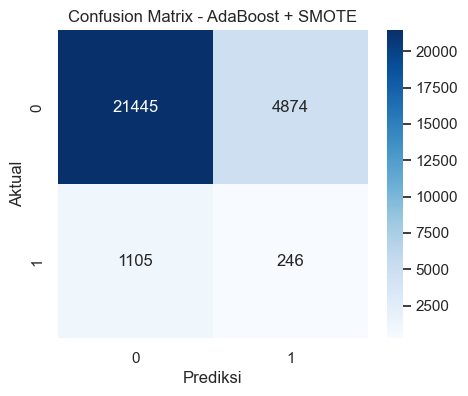

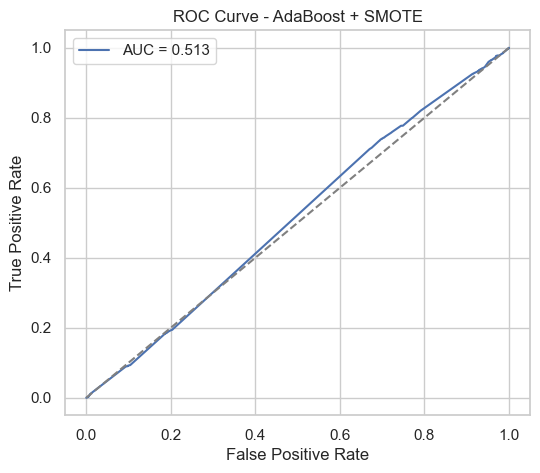

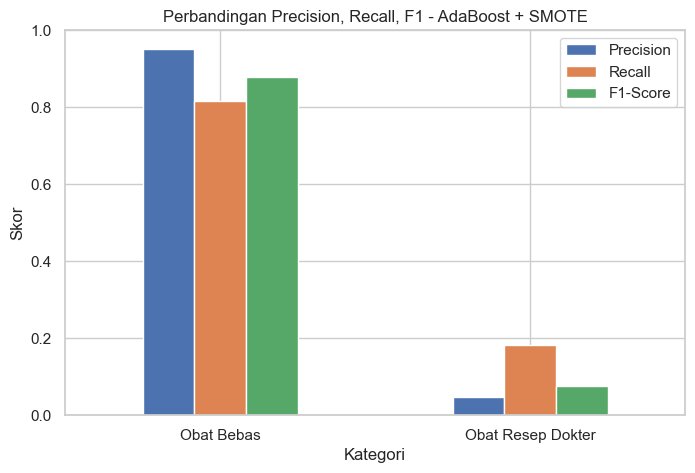

In [41]:
# ==============================================================
# 📈 7️⃣ VISUALISASI EVALUASI MODEL (CONFUSION MATRIX & ROC)
# ==============================================================

from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_fscore_support

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - AdaBoost + SMOTE")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# ROC Curve
if len(set(y_test)) == 2:
    fpr, tpr, _ = roc_curve((y_test == y_test.unique()[1]).astype(int), y_prob_smote)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_smote:.3f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - AdaBoost + SMOTE")
    plt.legend()
    plt.show()

# Grafik Precision, Recall, F1
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_smote, labels=model_smote.classes_)
metrics_df = pd.DataFrame({
    "Kategori": model_smote.classes_,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})
metrics_df.plot(x="Kategori", kind="bar", figsize=(8,5), ylim=(0,1))
plt.title("Perbandingan Precision, Recall, F1 - AdaBoost + SMOTE")
plt.ylabel("Skor")
plt.xticks(rotation=0)
plt.show()



=== Perbandingan Model ===
                    Model   Akurasi   ROC-AUC
0  AdaBoost (Tanpa SMOTE)  0.951175  0.491081
1        AdaBoost + SMOTE  0.783918  0.513498


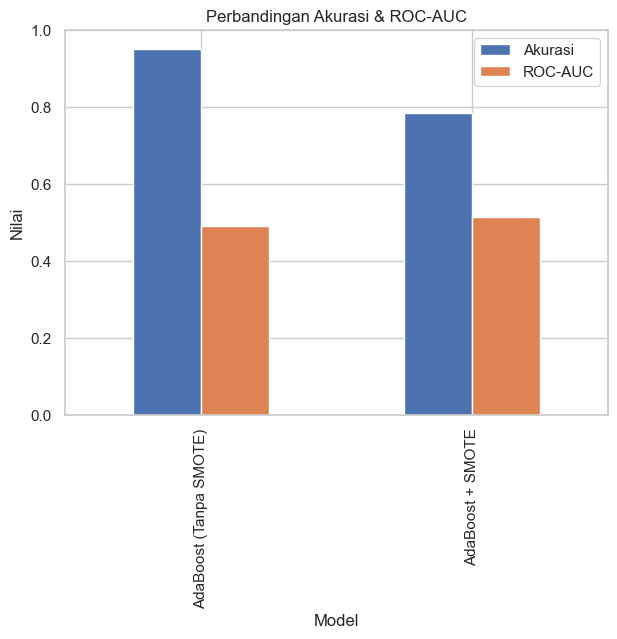

In [42]:
# ==============================================================
# 🧾 8️⃣ PERBANDINGAN MODEL: TANPA SMOTE vs DENGAN SMOTE
# ==============================================================

comparison = pd.DataFrame({
    "Model": ["AdaBoost (Tanpa SMOTE)", "AdaBoost + SMOTE"],
    "Akurasi": [acc_base, acc_smote],
    "ROC-AUC": [auc_base, auc_smote]
})

print("\n=== Perbandingan Model ===")
print(comparison)

comparison.plot(
    x="Model",
    y=["Akurasi", "ROC-AUC"],
    kind="bar",
    figsize=(7,5),
    ylim=(0,1),
    title="Perbandingan Akurasi & ROC-AUC"
)
plt.ylabel("Nilai")
plt.show()
